In [1]:
!unzip /content/ruenRoSBERTa_raw_embeddings.zip

Archive:  /content/ruenRoSBERTa_raw_embeddings.zip
  inflating: ruenRoSBERTa_raw_embeddings/train_index.npy  
  inflating: ruenRoSBERTa_raw_embeddings/train_embeddings.npy  
  inflating: ruenRoSBERTa_raw_embeddings/val_embeddings.npy  
  inflating: ruenRoSBERTa_raw_embeddings/test_embeddings.npy  
  inflating: ruenRoSBERTa_raw_embeddings/test_index.npy  
  inflating: ruenRoSBERTa_raw_embeddings/val_index.npy  


In [3]:
!unzip /content/model_and_metrics_embeddings_raw.zip

Archive:  /content/model_and_metrics_embeddings_raw.zip
  inflating: metrics_1/train_rmses.txt  
  inflating: metrics_1/val_losses.txt  
  inflating: metrics_1/train_losses.txt  
  inflating: metrics_1/val_rmses.txt  
  inflating: metrics_2/train_rmses.txt  
  inflating: metrics_2/val_losses.txt  
  inflating: metrics_2/train_losses.txt  
  inflating: metrics_2/val_rmses.txt  
  inflating: model_checkpoints_1/best_checkpoint.pt  
  inflating: model_checkpoints_2/best_checkpoint.pt  


In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
import torch.nn as nn
from collections import OrderedDict
# простая нейронная сеть, на вход которой подаются эмбеддинги
class RoSBERTRegressor_2layerhead(nn.Module):
    def __init__(self):
        super().__init__()

        # Store the pre-trained SBERT model
        self.hidden_layer_neurons = 256
        self.activation = nn.Sigmoid()
        self.regression_head = nn.Sequential(
                      OrderedDict([
                          ('regression_head1', nn.Linear(1024, self.hidden_layer_neurons)),
                          ('aciv1', self.activation),
                          ('regression_head2', nn.Linear(self.hidden_layer_neurons, 1)),
                      ])
                  )

    def forward(self, x):
        embeddings_x = nn.functional.normalize(x)
        res = self.regression_head(embeddings_x)

        return res

    def upload_checkpoint(self, path, device):
      self.regression_head.load_state_dict(torch.load(path, map_location=device))

    def save_checkpoint(self, path):
      torch.save(self.regression_head.state_dict(), path)
      print(f'savepath: {path}')


In [11]:
model_raw = RoSBERTRegressor_2layerhead()

model_raw.upload_checkpoint('/content/model_checkpoints_2/best_checkpoint.pt', device)

In [13]:
import pandas as pd
import numpy as np

# Create a Pandas DataFrame
df = pd.read_csv('/content/offers_data_numalphareduced.csv') # для проверки на CPU

df.rename(columns = {'p_full_description': 'description'}, inplace=True)

df.head()


,shareUrl,author_category,author_organization,full_description,region,description,price_value,price_value_m2,price_value_m2_ls
0,https://realty.yandex.ru/offer/522753573506055...,AGENCY,Петербургская Недвижимость,Номер объявления: 20590 - назовите его операто...,Nevsky,номер объявления: двадцать тысяч пятьсот девян...,13500000.0,413476.263400,413476.263400
1,https://realty.yandex.ru/offer/522692674778749...,DEVELOPER,Группа компаний ФСК,Цена со скидкой до 30% в прямой продаже от зас...,Nevsky,цена со скидкой до тридцать% в прямой продаже ...,7520853.0,211855.014085,211855.014085
2,https://realty.yandex.ru/offer/419286373934393...,DEVELOPER,ООО «ЛСР. Недвижимость–Северо-Запад»,Продается 1-комнатная квартира в ЖК «Октябрьск...,Nevsky,продается однокомнатная квартира в жилой компл...,12298650.0,331500.000000,331500.000000
3,https://realty.yandex.ru/offer/638098898688737...,AGENCY,NaN,Продаётся просторная 1к квартира по адресу ул....,Nevsky,продаётся просторная 1к квартира по адресу ул....,8050000.0,208010.335917,208010.335917
4,https://realty.yandex.ru/offer/490856214913453222,DEVELOPER,Петербургская Недвижимость,Продается уютная 1-комнатная квартира от застр...,Nevsky,продается уютная однокомнатная квартира от зас...,12500019.0,387838.008067,387838.008067


In [14]:
descriptions = df['description'].tolist()
prices = (df['price_value']/1e6).tolist()

In [86]:
test_idx = np.load('/content/ruenRoSBERTa_raw_embeddings/test_index.npy')
test_prices = np.array([prices[i] for i in test_idx])

val_idx = np.load('/content/ruenRoSBERTa_raw_embeddings/val_index.npy')
val_prices = np.array([prices[i] for i in val_idx])

## Эмбеддинги базовой модели

In [16]:
sample_dict_raw = {}
for sample in ['train', 'test', 'val']:
  sample_dict_raw[sample] = torch.from_numpy(np.load(f'/content/ruenRoSBERTa_raw_embeddings/{sample}_embeddings.npy'))

In [18]:
model_raw(sample_dict_raw['test']).shape

torch.Size([1835, 1])

In [19]:
import torch.nn as nn
import numpy as np
import torch
from tqdm import tqdm

def permutation_importance(model, data_array, target_array, n_iters=100, random_state=42):
  np.random.seed(random_state) # Use np.random.seed for numpy-based randomization

  # Ensure data_array and target_array are torch tensors
  if not isinstance(data_array, torch.Tensor):
    data_array = torch.from_numpy(data_array).float()
  if not isinstance(target_array, torch.Tensor):
    target_array = torch.from_numpy(target_array).float().reshape(-1, 1) # Reshape to [N, 1]

  # Set model to evaluation mode
  model.eval()

  # Calculate baseline error
  with torch.no_grad():
    baseline_predictions = model(data_array)
    baseline_error = torch.mean((baseline_predictions - target_array)**2).item() # Using MSE as error

  num_features = data_array.shape[1] # Number of embedding components
  importance_scores = np.zeros(num_features)

  # Loop through each feature (embedding component)
  for i in tqdm(range(num_features)):
    permuted_errors = []
    for _ in range(n_iters):
      # Create a copy of the data
      permuted_data = data_array.clone()

      # Permute the i-th column
      permuted_data[:, i] = permuted_data[np.random.permutation(len(permuted_data)), i]

      # Calculate error with permuted data
      with torch.no_grad():
        permuted_predictions = model(permuted_data)
        permuted_error = torch.mean((permuted_predictions - target_array)**2).item()
      permuted_errors.append(permuted_error)

    # Calculate average permuted error and importance score
    avg_permuted_error = np.mean(permuted_errors)
    importance_scores[i] = avg_permuted_error - baseline_error

  return importance_scores

In [43]:
importance_raw = permutation_importance(model_raw, sample_dict_raw['test'],test_prices, n_iters=50)


100%|██████████| 1024/1024 [22:04<00:00,  1.29s/it]


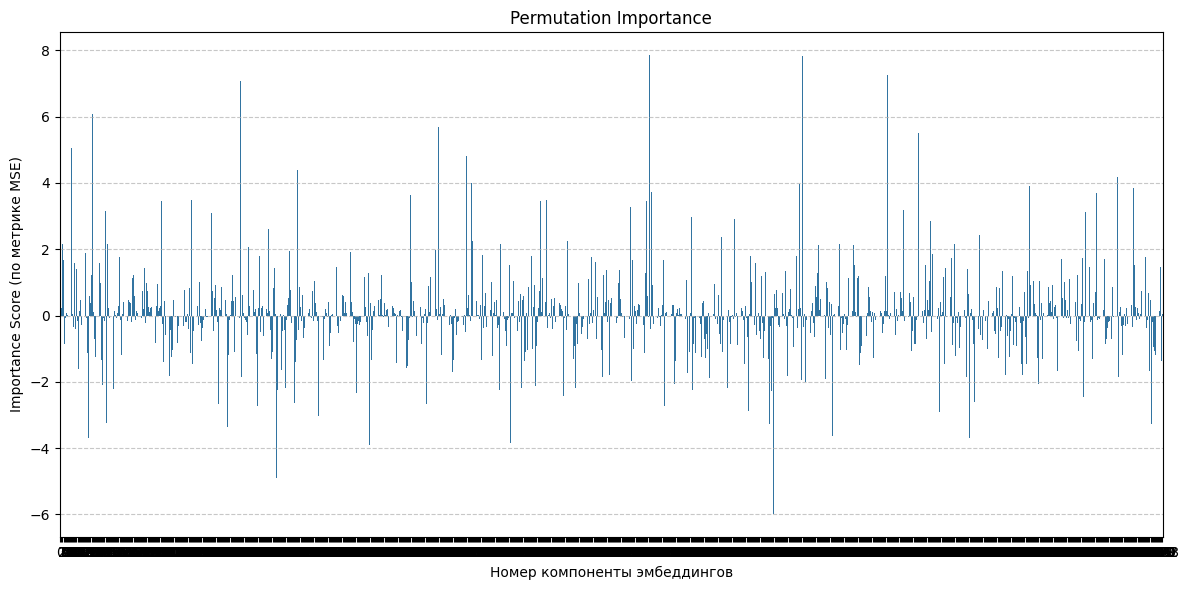

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_importance_scores(importance_scores, title='Permutation Importance', figsize=(12, 6)):
    plt.figure(figsize=figsize)
    sns.barplot(x=np.arange(len(importance_scores)), y=importance_scores)
    plt.title(title)
    plt.xlabel('Номер компоненты эмбеддингов')
    plt.ylabel('Importance Score (по метрике MSE)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_importance_scores(importance_raw)

In [41]:
importance_raw[np.abs(importance_raw)<0.1].shape[0]

205

In [37]:
corr_coeff = np.corrcoef(np.transpose(sample_dict_raw['test']))
np.abs(corr_coeff).min(), np.abs(np.tril(corr_coeff, k=-1)).max()

(np.float64(1.559624284980798e-07), np.float64(0.5625281685584376))

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 1835
Projected embeddings shape: (1835, 2)


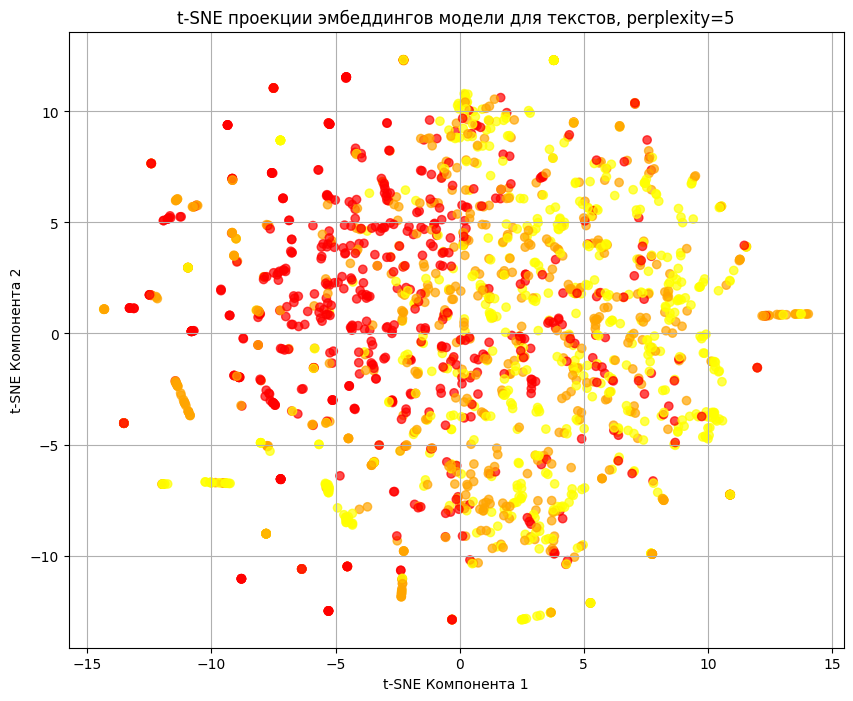

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 1835
Projected embeddings shape: (1835, 2)


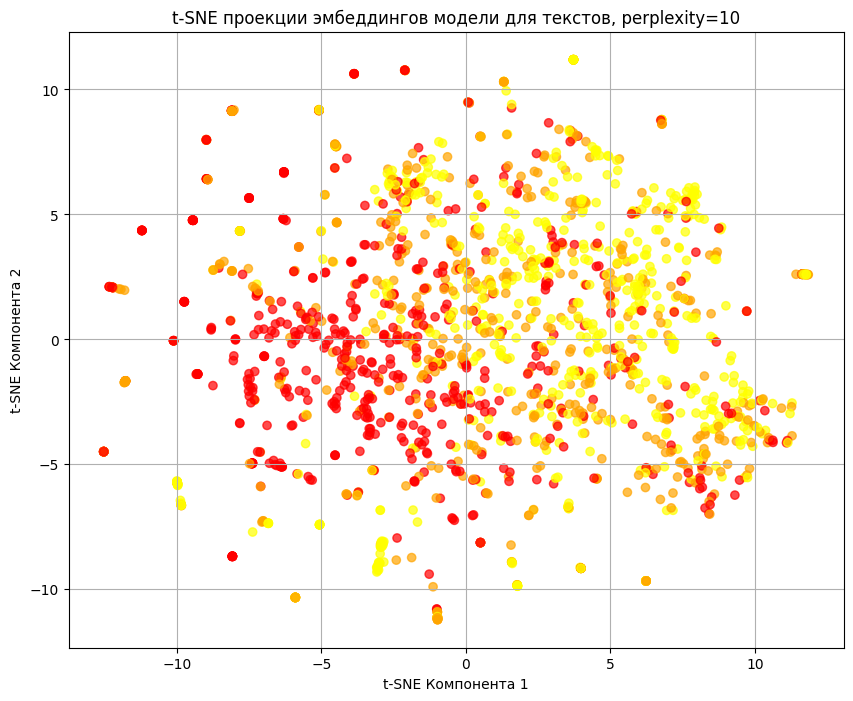

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 1835
Projected embeddings shape: (1835, 2)


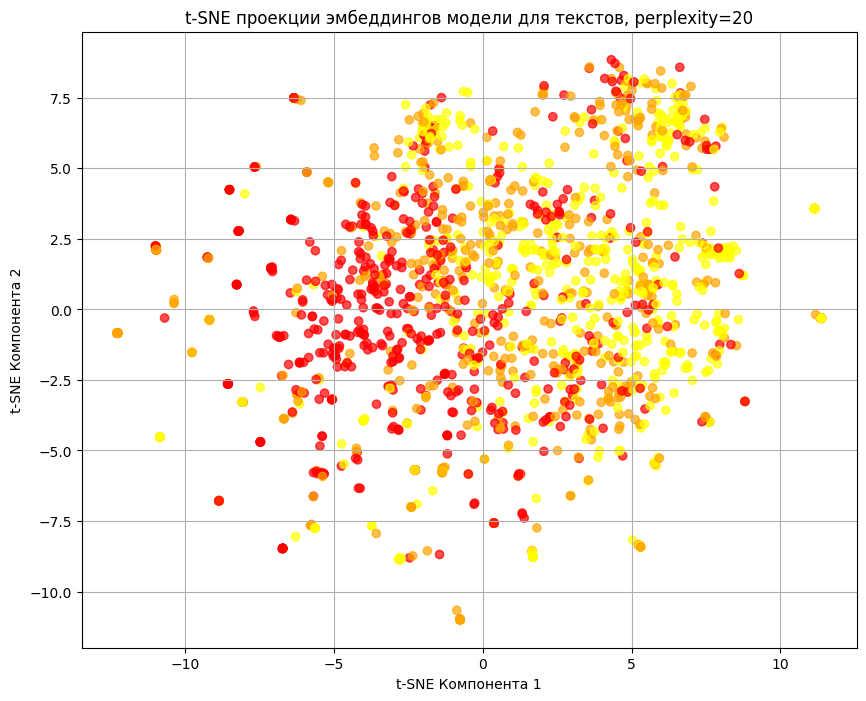

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 1835
Projected embeddings shape: (1835, 2)


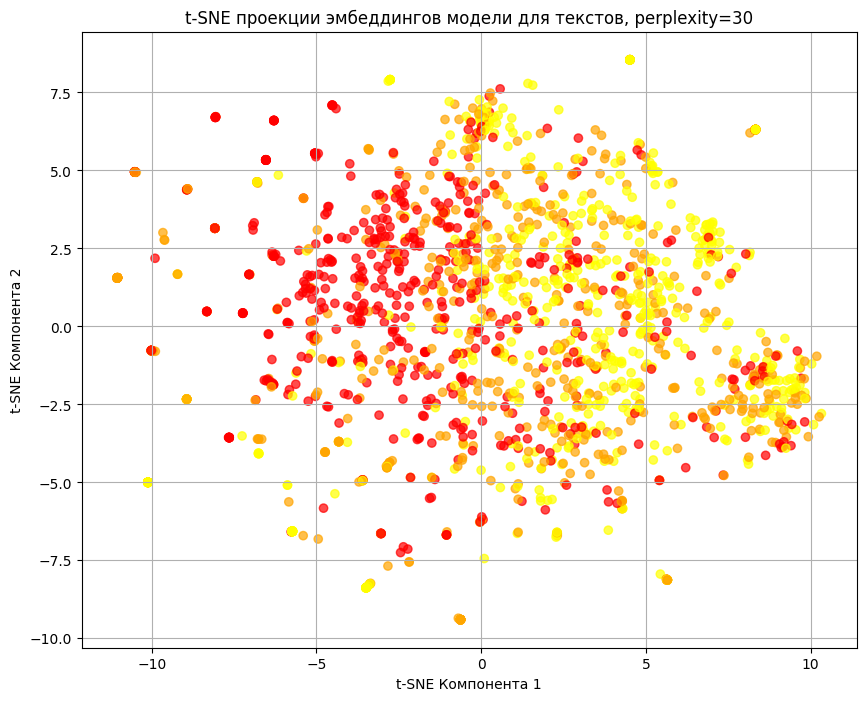

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 1835
Projected embeddings shape: (1835, 2)


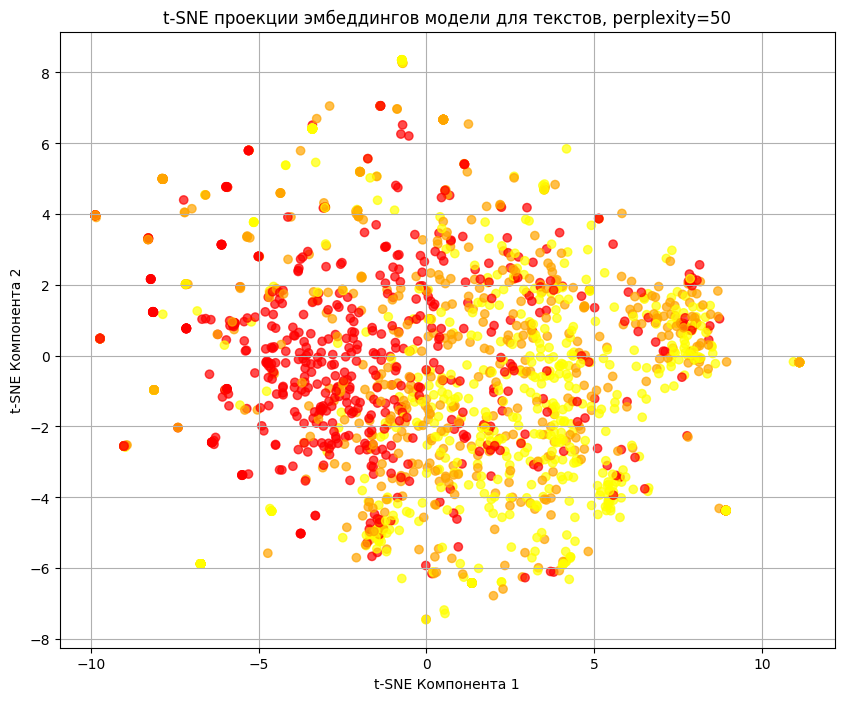

In [42]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Initialize t-SNE with 2 components for 2D visualization

for perpexity in [5, 10, 20, 30, 50]:

  tsne = TSNE(n_components=2, random_state=42, perplexity=perpexity, n_iter=300)

  # Fit t-SNE to the embeddings and transform them
  embeddings_2d = tsne.fit_transform(np.array(sample_dict_raw['test']))

  labels = pd.qcut(test_prices, q=3, labels=['yellow', 'orange', 'red'])

  print(f"Original embeddings shape: {len(sample_dict_raw['test'])}")
  print(f"Projected embeddings shape: {embeddings_2d.shape}")

  # Visualize the projected embeddings
  plt.figure(figsize=(10, 8))
  plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color=labels, alpha=0.7)
  plt.title(f't-SNE проекции эмбеддингов модели для текстов, perplexity={perpexity}')
  plt.xlabel('t-SNE Компонента 1')
  plt.ylabel('t-SNE Компонента 2')
  plt.grid(True)
  plt.show()

## Корреляционный анализ главных компонент эмбеддингов

In [51]:
from sklearn.decomposition import PCA

# Initialize PCA to explain 80% of the variance
pca = PCA(n_components=0.9, random_state=42)

# Fit PCA to the embeddings and transform them
pca.fit(sample_dict_raw['train'])

embeddings_pca = pca.transform(sample_dict_raw['test'])

print(f"Original embeddings shape: {sample_dict_raw['test'].shape}")
print(f"Reduced embeddings shape (explaining 80% variance): {embeddings_pca.shape}")

Original embeddings shape: torch.Size([1835, 1024])
Reduced embeddings shape (explaining 80% variance): (1835, 155)


In [52]:
pca.inverse_transform(embeddings_pca).shape

(1835, 1024)

In [64]:
from scipy.stats import spearmanr, pearsonr

res=[]
for i in range(embeddings_pca.shape[1]):
  corr = spearmanr(embeddings_pca[:, i], test_prices)[0]
  res.append(corr)

In [63]:
res

[np.float64(-0.2855809561989399),
 np.float64(0.016113687213275347),
 np.float64(-0.1887366020280039),
 np.float64(-0.010013620283803287),
 np.float64(-0.09683048188154765),
 np.float64(0.11248311932884147),
 np.float64(-0.09022404731463177),
 np.float64(-0.2507934127613573),
 np.float64(-0.013310871287455159),
 np.float64(0.039414657544602064),
 np.float64(0.09353645517077863),
 np.float64(0.08739560467436125),
 np.float64(-0.12390275638880312),
 np.float64(0.048209883374191756),
 np.float64(0.09297338514146977),
 np.float64(-0.03761636794067731),
 np.float64(0.053015483795124135),
 np.float64(0.02226665250823266),
 np.float64(0.036477412821708965),
 np.float64(-0.029230711022375535),
 np.float64(0.10862729940468682),
 np.float64(0.07390281108819505),
 np.float64(0.021808485241077546),
 np.float64(-0.00919726063131148),
 np.float64(0.02077633925774025),
 np.float64(0.019716886556886415),
 np.float64(-0.09276230835832525),
 np.float64(-0.029931469047856738),
 np.float64(0.0033284521221

## Абляционный анализ
Будем случайно заменять подмножетво компонент их средними.

Средние вычисляем на трейне

In [69]:
train_averages = sample_dict_raw['train'].mean(axis=0)

In [94]:
import torch.nn as nn
import numpy as np
import torch
from tqdm import tqdm

def ablation_study_function(model, data_array, target_array, train_averages, n_iterations=100, num_components_to_mask=100, random_state=42):
    np.random.seed(random_state)

    if not isinstance(data_array, torch.Tensor):
        data_array = torch.from_numpy(data_array).float()
    if not isinstance(target_array, torch.Tensor):
        target_array = torch.from_numpy(target_array).float().reshape(-1, 1)
    if not isinstance(train_averages, torch.Tensor):
        train_averages = torch.from_numpy(train_averages).float()

    model.eval()

    num_embedding_components = data_array.shape[1]
    ablation_metrics = []


    curr_avg_diff, prev_avg_diff = 0, -1

    with torch.no_grad():
      baseline_predictions = model(data_array)
      baseline_error = torch.mean((baseline_predictions - target_array)**2).item() # Using MSE as error

    for i in tqdm(range(n_iterations)):
        # Create a copy of the data to modify
        modified_data = data_array.clone()

        # Randomly select num_components_to_mask embedding component indices
        components_to_mask = np.random.choice(
            num_embedding_components,
            size=num_components_to_mask,
            replace=False
        )

        # Replace the selected components with their average values
        for comp_idx in components_to_mask:
            modified_data[:, comp_idx] = train_averages[comp_idx]

        # Calculate error with modified data
        with torch.no_grad():
            predictions = model(modified_data)
            error = torch.mean((predictions - target_array)**2).item() # Using MSE as error

        prev_avg_diff = curr_avg_diff
        rel_change = np.abs(error-baseline_error)/baseline_error
        curr_avg_diff = rel_change if i == 0 else (rel_change+prev_avg_diff*i)/(i+1)


        ablation_metrics.append(error)

    if (prev_avg_diff-curr_avg_diff) < 1e-4:
      print('Среднее сошлось!')

    ablation_metrics = np.array(ablation_metrics)
    print(f'Среднее относительное изменение {(np.abs(ablation_metrics - baseline_error)/baseline_error).mean()*100: .3f}')
    return ablation_metrics, ablation_metrics - baseline_error, baseline_error

In [95]:
ablation_results = ablation_study_function(model_raw, sample_dict_raw['val'],val_prices, train_averages, n_iterations=200,
                                           num_components_to_mask=145)

100%|██████████| 200/200 [00:06<00:00, 32.30it/s]

Среднее сошлось!
Среднее относительное изменение  5.582


In [96]:
ablation_results[2]

569.2615966796875

In [100]:
ablation_results = ablation_study_function(model_raw, sample_dict_raw['test'],test_prices, train_averages, n_iterations=300,
                                           num_components_to_mask=145)

100%|██████████| 300/300 [00:14<00:00, 20.83it/s]

Среднее сошлось!
Среднее относительное изменение  7.183


In [98]:
ablation_results[2]

1024.4141845703125

<Axes: ylabel='Frequency'>

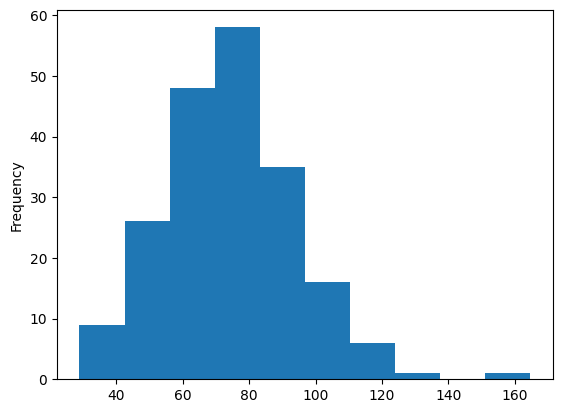

In [99]:
pd.Series(ablation_results[1]).plot(kind='hist')

In [106]:
с= ablation_study_function(model_raw, sample_dict_raw['test'],test_prices, train_averages, n_iterations=200,
                                           num_components_to_mask=250)

100%|██████████| 200/200 [00:16<00:00, 12.07it/s]

Среднее относительное изменение  19.389


In [105]:
9

9